In [1]:
import os
import pandas as pd
import scanpy as sc
from tqdm import tqdm

In [2]:
# set directory to be /gpfs/commons/datasets/controlled/BRAIN_NeMO/human-cortex-mtg/featureCounts
os.chdir('/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-cortex-mtg/featureCounts')
# check working directory
os.getcwd()

'/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-cortex-mtg/featureCounts'

In [3]:
# get a list of the count files in the directory (all _counts.txt files)
count_files = [f for f in os.listdir() if f.endswith('_counts.txt')]
print(f"The number of files here is {len(count_files)}")

The number of files here is 208


In [4]:
dfs = []
for file in tqdm(count_files):
    df = pd.read_csv(file, skiprows=1, delimiter='\t', index_col=0)
    # Keep just index column and last column 
    df = df.iloc[:, [-1]]
    dfs.append(df)

100%|██████████| 208/208 [02:26<00:00,  1.42it/s]


In [5]:
combined_df = pd.concat(dfs, axis=1)

In [6]:
combined_df.head()

,F2S4_170405_031_D01/Aligned.sortedByCoord.out.bam.CB.bam,F2S4_170405_019_A01/Aligned.sortedByCoord.out.bam.CB.bam,F2S4_170405_027_B01/Aligned.sortedByCoord.out.bam.CB.bam,F2S4_170405_029_A01/Aligned.sortedByCoord.out.bam.CB.bam,F2S4_170405_008_C01/Aligned.sortedByCoord.out.bam.CB.bam,F2S4_170405_013_E01/Aligned.sortedByCoord.out.bam.CB.bam,F2S4_170405_024_F01/Aligned.sortedByCoord.out.bam.CB.bam,F2S4_170405_010_C01/Aligned.sortedByCoord.out.bam.CB.bam,F2S4_170405_030_E01/Aligned.sortedByCoord.out.bam.CB.bam,F2S4_170405_031_A01/Aligned.sortedByCoord.out.bam.CB.bam,...,F2S4_170405_031_F01/Aligned.sortedByCoord.out.bam.CB.bam,F2S4_170405_014_D01/Aligned.sortedByCoord.out.bam.CB.bam,F2S4_170405_020_F01/Aligned.sortedByCoord.out.bam.CB.bam,F2S4_170405_021_F01/Aligned.sortedByCoord.out.bam.CB.bam,F2S4_170405_028_A01/Aligned.sortedByCoord.out.bam.CB.bam,F2S4_170405_023_F01/Aligned.sortedByCoord.out.bam.CB.bam,F2S4_170405_012_H01/Aligned.sortedByCoord.out.bam.CB.bam,F2S4_170405_023_A01/Aligned.sortedByCoord.out.bam.CB.bam,F2S4_170405_026_H01/Aligned.sortedByCoord.out.bam.CB.bam,F2S4_170405_006_C01/Aligned.sortedByCoord.out.bam.CB.bam
Geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000290825.1,1,1,1,0,24,0,2,0,2,23,...,0,0,50,4,0,19,5,16,3,0
ENSG00000223972.6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000227232.6,66,84,1,25,63,33,70,33,138,31,...,17,1,46,84,16,14,60,63,3,8
ENSG00000278267.1,0,0,0,0,0,1,0,0,0,0,...,0,0,3,0,1,0,0,0,0,1
ENSG00000243485.5,0,0,0,0,0,0,0,148,0,0,...,0,0,0,0,0,0,0,0,0,0


In [50]:
adata = sc.AnnData(combined_df.T)
adata.obs_names_make_unique()

In [51]:
# clean up cell ids in adata.obs keep only everything before "/Aligned"
adata.obs.index = adata.obs.index.str.split('/Aligned').str[0]

# make a new column in obs to show the first part in the cell id , second, part, third part and 4th part "_" split 
adata.obs['cell_id_1'] = adata.obs.index.str.split('_').str[0]
adata.obs['cell_id_2'] = adata.obs.index.str.split('_').str[1]
adata.obs['cell_id_3'] = adata.obs.index.str.split('_').str[2]
adata.obs['cell_id_4'] = adata.obs.index.str.split('_').str[3]
adata.obs

,cell_id_1,cell_id_2,cell_id_3,cell_id_4
F2S4_170405_031_D01,F2S4,170405,031,D01
F2S4_170405_019_A01,F2S4,170405,019,A01
F2S4_170405_027_B01,F2S4,170405,027,B01
F2S4_170405_029_A01,F2S4,170405,029,A01
F2S4_170405_008_C01,F2S4,170405,008,C01
...,...,...,...,...
F2S4_170405_023_F01,F2S4,170405,023,F01
F2S4_170405_012_H01,F2S4,170405,012,H01
F2S4_170405_023_A01,F2S4,170405,023,A01
F2S4_170405_026_H01,F2S4,170405,026,H01


In [24]:
# gtf file 
gtf_file = "/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-reference/gencode/gencode.v45.primary_assembly.annotation.gtf"

# read gtf file
gene_mapping = {}

# Parse GTF file to get transcript coordinates
with open(gtf_file, 'r') as gtf:
    for line in gtf:
        if line.startswith('#'):
            continue
        fields = line.strip().split('\t')
        if fields[2] != 'gene':
            continue
        gene_id = fields[8].split(';')[0].split('"')[1] #gene id
        gene_type = fields[8].split(';')[1].split('"')[1] #gene type
        gene_name =  fields[8].split(';')[2].split('"')[1] #gene gene_name

        # save the mapping
        gene_mapping[gene_id] = (gene_name, gene_type)

In [25]:
# convert gene_mapping to dataframe 
gene_mapping_df = pd.DataFrame(gene_mapping).T

In [26]:
# add column names index should be "Geneid", "gene_name", "gene_type"
gene_mapping_df.columns = ["gene_name", "gene_type"]
gene_mapping_df["gene_id"] = gene_mapping_df.index

In [44]:
# remove columns with duplciated gene_names 
gene_mapping_df = gene_mapping_df.drop_duplicates("gene_name")

# remove any rows where gene_name is NA 
gene_mapping_df = gene_mapping_df.dropna(subset=["gene_name"])

# remove any rows where gene_name is "nan"
gene_mapping_df = gene_mapping_df[gene_mapping_df["gene_name"] != "nan"]

# keep only rows where gene_mapping_df gene_type is 'protein_coding' or 'lncRNA'
gene_mapping_df = gene_mapping_df[gene_mapping_df["gene_type"].isin(['protein_coding', 'lncRNA'])]

# remove rows where gene_name starts with "ENSG"
gene_mapping_df = gene_mapping_df[~gene_mapping_df["gene_name"].str.startswith("ENSG")]

In [52]:
adata.var_names

Index(['ENSG00000290825.1', 'ENSG00000223972.6', 'ENSG00000227232.6',
       'ENSG00000278267.1', 'ENSG00000243485.5', 'ENSG00000284332.1',
       'ENSG00000237613.2', 'ENSG00000268020.3', 'ENSG00000290826.1',
       'ENSG00000240361.3',
       ...
       'ENSG00000273739.1', 'ENSG00000276700.1', 'ENSG00000276312.1',
       'ENSG00000275757.1', 'ENSG00000278573.1', 'ENSG00000276017.1',
       'ENSG00000278817.1', 'ENSG00000277196.4', 'ENSG00000278625.1',
       'ENSG00000277374.1'],
      dtype='object', name='Geneid', length=63241)

In [49]:
gene_mapping_df[gene_mapping_df["gene_id"] == "ENSG00000278267.1"]

,gene_name,gene_type,gene_id


In [53]:
# add column for gene name 
adata.var['gene_id'] = adata.var.index

# subset adata to only variables that are in gene_mapping_df["gene_id"]
adata = adata[:, adata.var["gene_id"].isin(gene_mapping_df["gene_id"])]

# merge with gene_mapping_df
adata.var = adata.var.merge(gene_mapping_df, on='gene_id')
adata.var

,gene_id,gene_name,gene_type
0,ENSG00000290825.1,DDX11L2,lncRNA
1,ENSG00000243485.5,MIR1302-2HG,lncRNA
2,ENSG00000237613.2,FAM138A,lncRNA
3,ENSG00000186092.7,OR4F5,protein_coding
4,ENSG00000284733.2,OR4F29,protein_coding
...,...,...,...
25313,ENSG00000198886.2,MT-ND4,protein_coding
25314,ENSG00000198786.2,MT-ND5,protein_coding
25315,ENSG00000198695.2,MT-ND6,protein_coding
25316,ENSG00000198727.2,MT-CYB,protein_coding


In [76]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [77]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

In [54]:
# make adata.var.index be gene_name 
adata.var.index = adata.var['gene_name']

In [55]:
# QC 
sc.pp.calculate_qc_metrics(
    adata, inplace=True, log1p=True
)

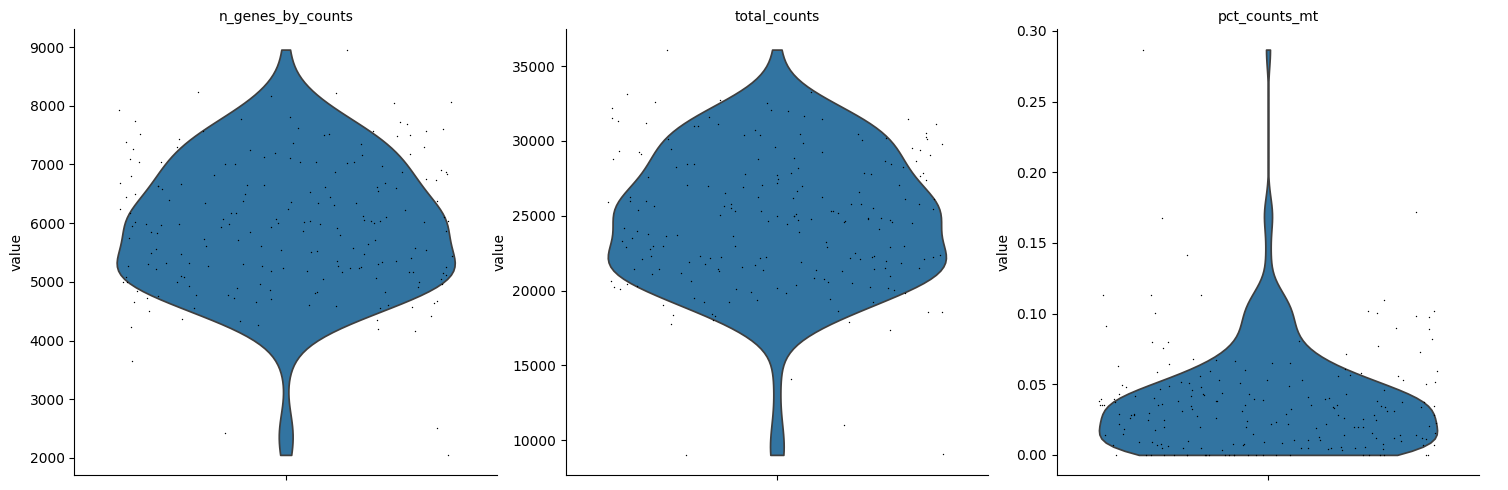

In [78]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

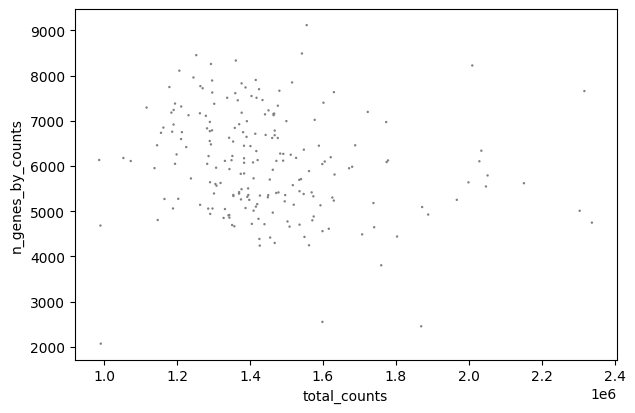

In [57]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", size=12)

In [58]:
# Example preprocessing steps
sc.pp.filter_cells(adata, min_genes=100)
print(adata)
sc.pp.filter_genes(adata, min_cells=10)
print(adata)

AnnData object with n_obs × n_vars = 208 × 25318
    obs: 'cell_id_1', 'cell_id_2', 'cell_id_3', 'cell_id_4', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes'
    var: 'gene_id', 'gene_name', 'gene_type', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
AnnData object with n_obs × n_vars = 208 × 16515
    obs: 'cell_id_1', 'cell_id_2', 'cell_id_3', 'cell_id_4', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes'
    var: 'gene_id', 'gene_name', 'gene_type', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'


In [59]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

In [60]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

In [61]:
sc.pp.highly_variable_genes(adata, n_top_genes=3000)

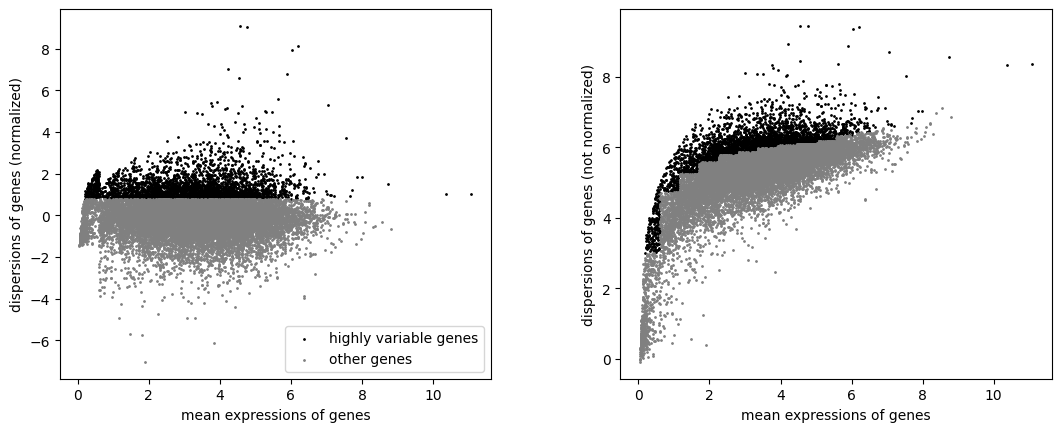

In [62]:
sc.pl.highly_variable_genes(adata)

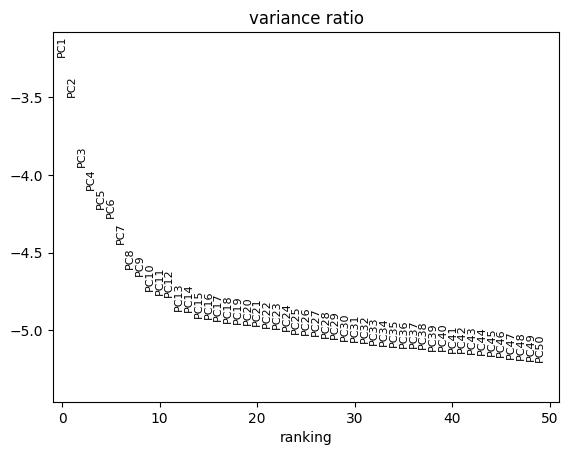

In [63]:
# Perform dimensionality reduction using PCA
sc.tl.pca(adata)

sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

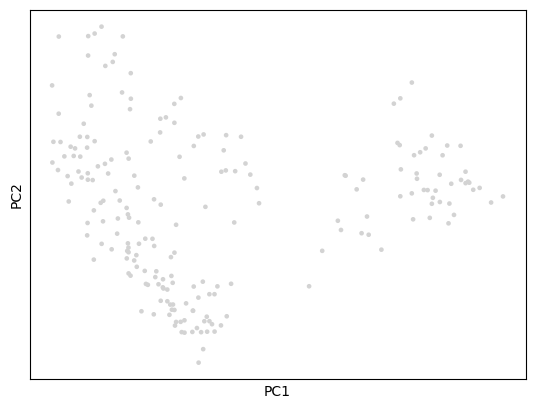

In [64]:
sc.pl.pca(adata, size=45)

In [65]:
sc.pp.neighbors(adata)

In [66]:
sc.tl.umap(adata)

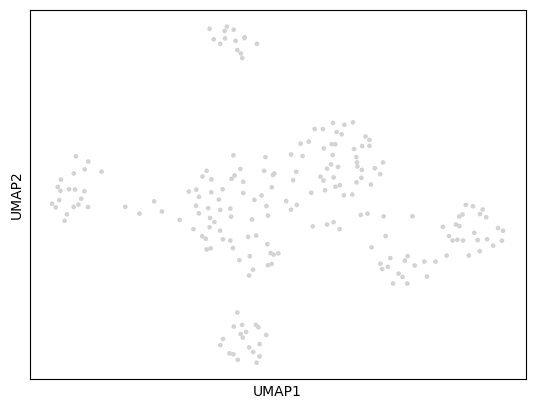

In [67]:
sc.pl.umap(adata, size=45)

In [68]:
# Using the igraph implementation and a fixed number of iterations can be significantly faster, especially for larger datasets
sc.tl.leiden(adata, flavor="igraph", n_iterations=10)

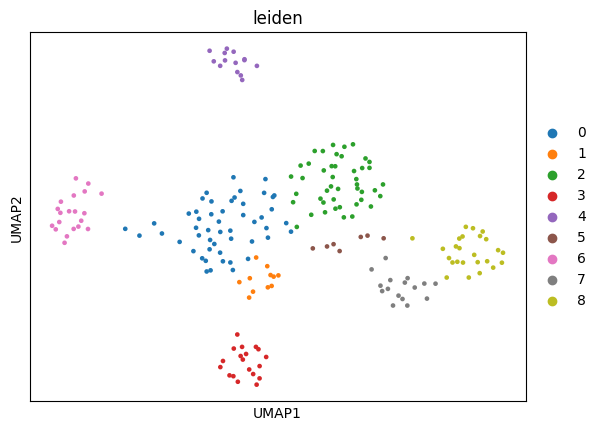

In [69]:
sc.pl.umap(adata, color=["leiden"], size=45)

In [70]:
adata.obs.cell_id_4.unique()

['D01', 'A01', 'B01', 'C01', 'E01', 'F01', 'H01', 'G01']
Categories (8, object): ['A01', 'B01', 'C01', 'D01', 'E01', 'F01', 'G01', 'H01']

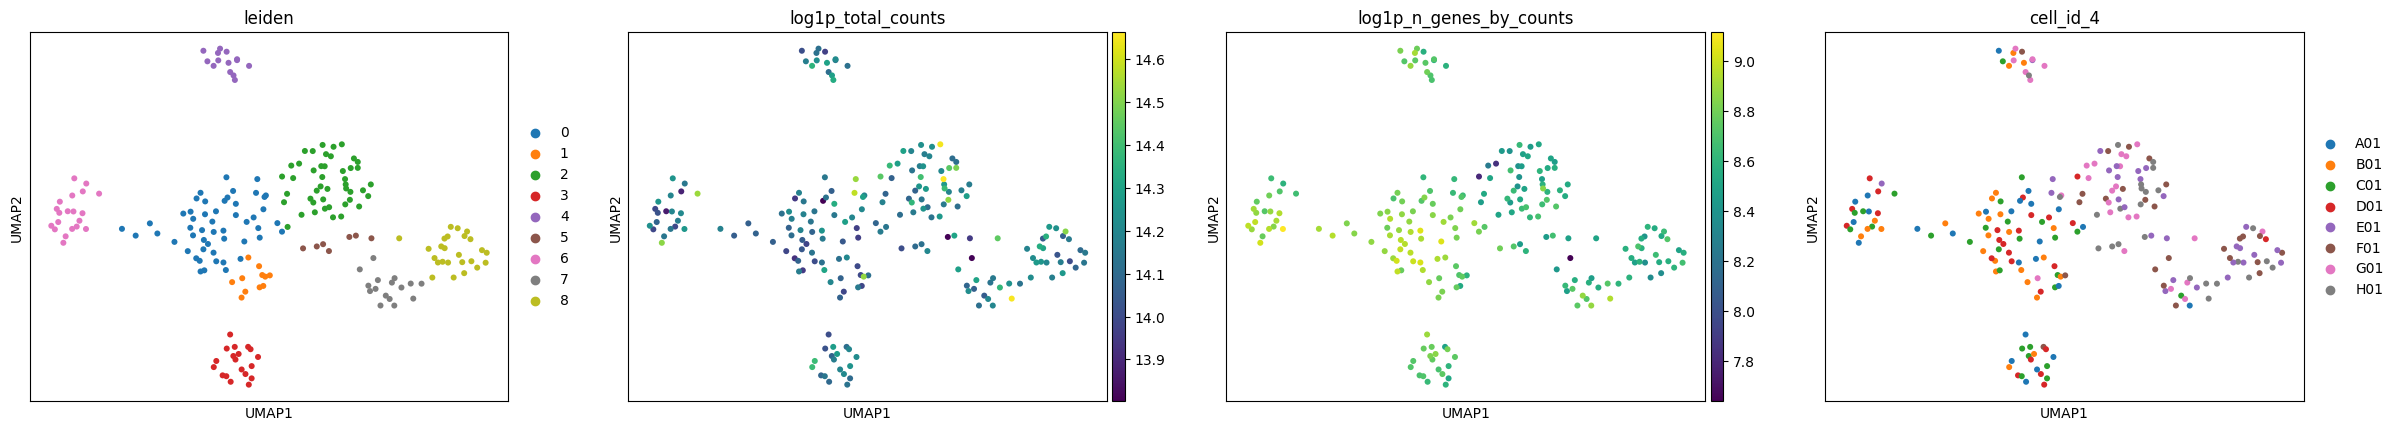

In [71]:
sc.pl.umap(
    adata,
    color=["leiden", "log1p_total_counts", "log1p_n_genes_by_counts", "cell_id_4"],
    ncols=4, size=75
)

In [72]:
for res in [0.02, 0.5, 2.0]:
    sc.tl.leiden(
        adata, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph"
    )

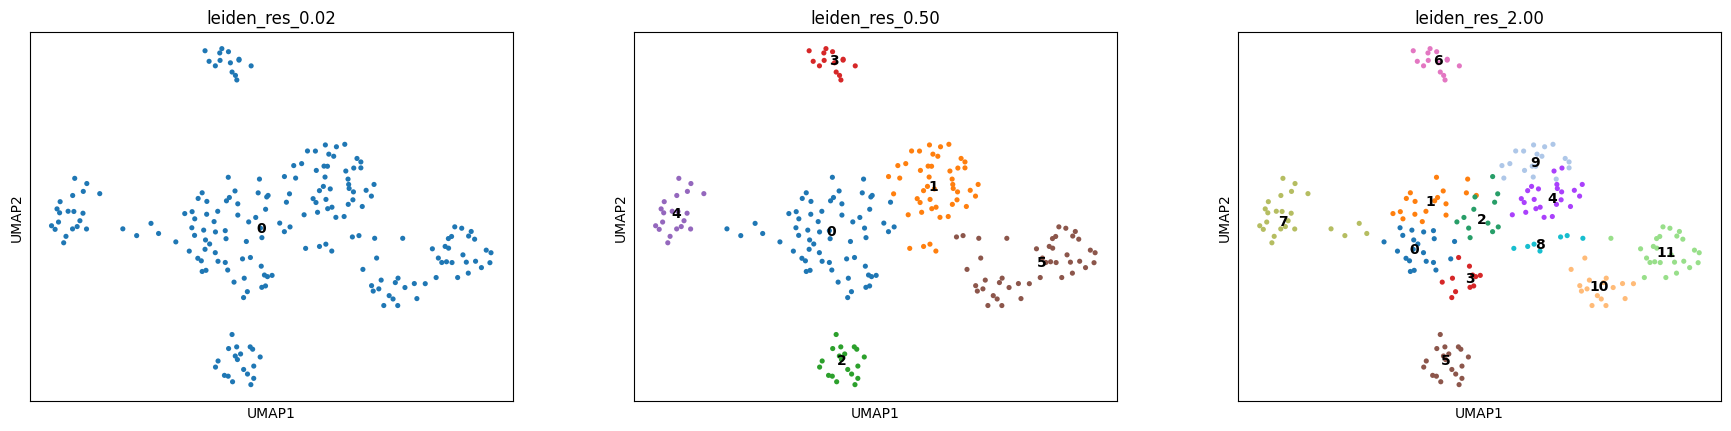

In [73]:
sc.pl.umap(
    adata,
    color=["leiden_res_0.02", "leiden_res_0.50", "leiden_res_2.00"],
    legend_loc="on data", size=55
)

In [74]:
# Obtain cluster-specific differentially expressed genes
sc.tl.rank_genes_groups(adata, groupby="leiden_res_0.50", method="wilcoxon")

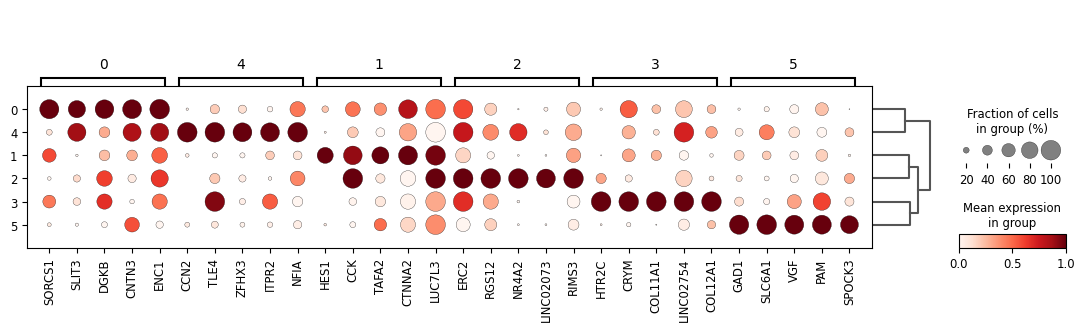

In [75]:
sc.pl.rank_genes_groups_dotplot(
    adata, groupby="leiden_res_0.50", standard_scale="var", n_genes=5
)

In [82]:
sc.get.rank_genes_groups_df(adata, group="1").head(10).names


0         HES1
1          CCK
2        TAFA2
3       CTNNA2
4       LUC7L3
5         JUNB
6        P2RY6
7    LINC01141
8        TNNT2
9         EBF1
Name: names, dtype: object

In [86]:
# get cell labels for which cluster they get put into 
adata.obs["leiden_res_0.50"].value_counts()

leiden_res_0.50
0    64
1    47
5    44
4    20
2    19
3    14
Name: count, dtype: int64

In [87]:
adata.obs["leiden_res_0.50"]

F2S4_170405_031_D01    0
F2S4_170405_019_A01    0
F2S4_170405_027_B01    0
F2S4_170405_029_A01    0
F2S4_170405_008_C01    0
                      ..
F2S4_170405_023_F01    5
F2S4_170405_012_H01    5
F2S4_170405_023_A01    0
F2S4_170405_026_H01    3
F2S4_170405_006_C01    3
Name: leiden_res_0.50, Length: 208, dtype: category
Categories (6, object): ['0', '1', '2', '3', '4', '5']

In [91]:
os.getcwd()

'/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-cortex-mtg/featureCounts'

In [92]:
# outputfile_path '/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-cortex-mtg/'
# save ad.obs as dataframe to csv file in outputfile_path

adata.obs.to_csv('/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-cortex-mtg/mtg_nuclei_gene_expression_leiden_clusters.csv', sep="\t")